Estimated Mean: 48.97683601515181
Standard Error: 0.8815663256086053
95% Confidence Interval: [47.27663575 50.62851486]


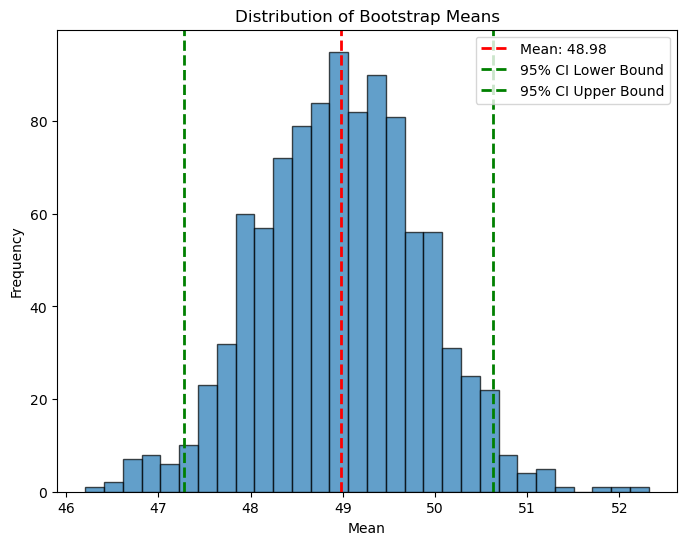

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example dataset
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 100 data points from a normal distribution

# Bootstrapping function
def bootstrap(data, n_iterations=1000, statistic=np.mean):
    n = len(data)
    bootstrap_stats = []
    
    for _ in range(n_iterations):
        # Resample with replacement
        resample = np.random.choice(data, size=n, replace=True)
        # Calculate the statistic (e.g., mean)
        stat = statistic(resample)
        bootstrap_stats.append(stat)
    
    return bootstrap_stats

# Perform bootstrapping
bootstrap_means = bootstrap(data, n_iterations=1000)

# Analyze results
mean_estimate = np.mean(bootstrap_means)
std_error = np.std(bootstrap_means, ddof=1)  # Standard error
confidence_interval = np.percentile(bootstrap_means, [2.5, 97.5])  # 95% confidence interval

print(f"Estimated Mean: {mean_estimate}")
print(f"Standard Error: {std_error}")
print(f"95% Confidence Interval: {confidence_interval}")

# Plot the distribution of bootstrap means
plt.figure(figsize=(8, 6))
plt.hist(bootstrap_means, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mean_estimate, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_estimate:.2f}')
plt.axvline(confidence_interval[0], color='green', linestyle='dashed', linewidth=2, label='95% CI Lower Bound')
plt.axvline(confidence_interval[1], color='green', linestyle='dashed', linewidth=2, label='95% CI Upper Bound')
plt.title("Distribution of Bootstrap Means")
plt.xlabel("Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression

# Example dataset for regression
X = np.random.rand(100, 1) * 10  # Feature
y = 2 * X.squeeze() + np.random.normal(scale=2, size=100)  # Target with noise

# Bootstrapping regression coefficients
def bootstrap_regression(X, y, n_iterations=1000):
    n = len(X)
    bootstrap_coeffs = []
    
    for _ in range(n_iterations):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        X_resample, y_resample = X[indices], y[indices]
        
        # Fit regression model
        model = LinearRegression()
        model.fit(X_resample, y_resample)
        bootstrap_coeffs.append(model.coef_[0])
    
    return bootstrap_coeffs

# Perform bootstrapping
bootstrap_coeffs = bootstrap_regression(X, y, n_iterations=1000)

# Analyze results
coeff_estimate = np.mean(bootstrap_coeffs)
coeff_std_error = np.std(bootstrap_coeffs, ddof=1)
coeff_confidence_interval = np.percentile(bootstrap_coeffs, [2.5, 97.5])

print(f"Estimated Coefficient: {coeff_estimate}")
print(f"Standard Error: {coeff_std_error}")
print(f"95% Confidence Interval: {coeff_confidence_interval}")

Estimated Coefficient: 1.9061557909509366
Standard Error: 0.05908597045451289
95% Confidence Interval: [1.79202997 2.03104655]
